## Stage 1: Boundary / Sandhi Window Detection

In [1]:
import pandas as pd
import numpy as np
import torch.nn as nn
import torch
import re

from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

In [2]:
DATA_XLSX = "/kaggle/input/datasets/tanujsaxena/sandhi-data/sandhi_data.xlsx"
df = pd.read_excel(DATA_XLSX)

print("Shape:", df.shape)
df = df.rename(columns={
    df.columns[0]: "raw",
    df.columns[1]: "split"
})
print("Columns:", df.columns.tolist())
df.head(5)

Shape: (13930, 2)
Columns: ['raw', 'split']


,raw,split
0,प्रथमोऽङ्कः,प्रथमः+अङ्कः
1,शब्द इव,शब्दः+इव
2,इत इतः,इतः+इतः
3,कुतो नु,कुतः+नु
4,खल्वेष समुत्थितो समुत्थितो ध्वनिः,खलु+एषः+समुत्थितः+समुत्थितः+ध्वनिः


In [3]:
def extract_word_pairs(raw, split):
    if not isinstance(raw, str) or not isinstance(split, str):
        return []

    raw = raw.strip()
    split = split.strip()

    if raw == "" or split == "":
        return []

    raw_words = raw.split()
    split_parts = split.split("+")

    pairs = []
    idx = 0

    for raw_word in raw_words:
        combined = ""
        while idx < len(split_parts):
            combined += split_parts[idx]
            idx += 1
            if len(combined.replace("्", "")) >= len(raw_word.replace("्", "")):
                pairs.append((raw_word, combined))
                break
            combined += "+"

    return pairs

samples = []
for _, row in df.iterrows():
    samples.extend(extract_word_pairs(row["raw"], row["split"]))

word_df = pd.DataFrame(samples, columns=["sandhied", "gold_split"])
word_df.head(10)

,sandhied,gold_split
0,प्रथमोऽङ्कः,प्रथमः+अङ्कः
1,शब्द,शब्दः
2,इव,इव
3,इत,इतः
4,इतः,इतः
5,कुतो,कुतः
6,नु,नु
7,खल्वेष,खलु+एषः
8,समुत्थितो,समुत्थितः
9,समुत्थितो,समुत्थितः


In [4]:
def get_boundary_positions(split_word):
    parts = split_word.split("+")
    if len(parts) <= 1:
        return []
    return [len(parts[0])]

word_df["boundary_positions"] = word_df["gold_split"].apply(get_boundary_positions)
word_df.head()

,sandhied,gold_split,boundary_positions
0,प्रथमोऽङ्कः,प्रथमः+अङ्कः,[6]
1,शब्द,शब्दः,[]
2,इव,इव,[]
3,इत,इतः,[]
4,इतः,इतः,[]


In [5]:
def boundary_vector(word, positions):
    vec = [0] * len(word)
    for p in positions:
        if p < len(word):
            vec[p] = 1
    return vec

word_df["boundary_vector"] = word_df.apply(
    lambda r: boundary_vector(r["sandhied"], r["boundary_positions"]),
    axis=1
)

In [6]:
PAD = "<PAD>"

chars = set()
for w in word_df["sandhied"]:
    chars.update(w)

char2idx = {PAD: 0}
for ch in sorted(chars):
    char2idx[ch] = len(char2idx)

idx2char = {v: k for k, v in char2idx.items()}
VOCAB_SIZE = len(char2idx)

print("Vocab size:", VOCAB_SIZE)

Vocab size: 81


In [7]:
MAX_LEN = word_df["sandhied"].apply(len).max()

def encode(word):
    return [char2idx[c] for c in word]

def pad(seq):
    return seq + [0] * (MAX_LEN - len(seq))

word_df["input_ids"] = word_df["sandhied"].apply(lambda x: pad(encode(x)))
word_df["labels"] = word_df["boundary_vector"].apply(lambda x: pad(x))

In [8]:
class SandhiBoundaryDataset(Dataset):
    def __init__(self, df):
        self.X = df["input_ids"].tolist()
        self.y = df["labels"].tolist()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.X[idx], dtype=torch.long),
            torch.tensor(self.y[idx], dtype=torch.float)
        )

In [9]:
train_df, val_df = train_test_split(word_df, test_size=0.1, random_state=42)

train_loader = DataLoader(SandhiBoundaryDataset(train_df), batch_size=32, shuffle=True)
val_loader = DataLoader(SandhiBoundaryDataset(val_df), batch_size=32)

In [10]:
class BoundaryBiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True
        )
        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.lstm(x)
        return self.fc(out).squeeze(-1)

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = BoundaryBiLSTM(VOCAB_SIZE).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

EPOCHS = 10

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

In [12]:
def compute_accuracy(preds, labels):
    correct = (preds == labels).sum().item()
    total = labels.numel()
    return correct / total

In [13]:
for epoch in range(EPOCHS):

    model.train()

    train_loss = 0
    train_acc = 0

    for x, y in tqdm(train_loader):

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()
        acc = compute_accuracy(preds, y)

        train_loss += loss.item()
        train_acc += acc

    model.eval()

    val_loss = 0
    val_acc = 0

    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            y = y.to(device)

            outputs = model(x)
            loss = criterion(outputs, y)
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()
            acc = compute_accuracy(preds, y)
            val_loss += loss.item()
            val_acc += acc

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)

    avg_train_acc = train_acc / len(train_loader)
    avg_val_acc = val_acc / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    train_accuracies.append(avg_train_acc)
    val_accuracies.append(avg_val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Train Acc: {avg_train_acc:.4f}"
    )
    print(
        f"Val Loss:   {avg_val_loss:.4f} | "
        f"Val Acc:   {avg_val_acc:.4f}"
    )
    print("-" * 50)

100%|██████████| 551/551 [00:03<00:00, 156.20it/s]


Epoch 1/10
Train Loss: 0.0273 | Train Acc: 0.9965
Val Loss:   0.0090 | Val Acc:   0.9969
--------------------------------------------------


100%|██████████| 551/551 [00:02<00:00, 199.45it/s]


Epoch 2/10
Train Loss: 0.0068 | Train Acc: 0.9976
Val Loss:   0.0060 | Val Acc:   0.9979
--------------------------------------------------


100%|██████████| 551/551 [00:02<00:00, 199.89it/s]


...

Epoch 8/10
Train Loss: 0.0027 | Train Acc: 0.9992
Val Loss:   0.0039 | Val Acc:   0.9988
--------------------------------------------------


100%|██████████| 551/551 [00:02<00:00, 198.41it/s]


Epoch 9/10
Train Loss: 0.0023 | Train Acc: 0.9993
Val Loss:   0.0040 | Val Acc:   0.9988
--------------------------------------------------


100%|██████████| 551/551 [00:02<00:00, 198.19it/s]


Epoch 10/10
Train Loss: 0.0021 | Train Acc: 0.9993
Val Loss:   0.0043 | Val Acc:   0.9988
--------------------------------------------------


In [14]:
def predict_boundary(word):
    model.eval()

    encoded = [char2idx[c] for c in word]
    encoded = encoded + [0] * (MAX_LEN - len(encoded))
    x = torch.tensor([encoded], dtype=torch.long).to(device)

    with torch.no_grad():
        logits = model(x)
        probs = torch.sigmoid(logits).squeeze().cpu().numpy()

    boundary = int(probs.argmax())
    return boundary, probs

In [15]:
samples = word_df.sample(5)

for _, row in samples.iterrows():
    word = row["sandhied"]
    gold = row["boundary_positions"]

    pred_boundary, probs = predict_boundary(word)

    print("Word :", word)
    print("Gold :", gold)
    print("Pred :", pred_boundary)
    print("-" * 40)

Word : मृजेर्वृद्धिः
Gold : [5]
Pred : 5
----------------------------------------
Word : निजं
Gold : []
Pred : 1
----------------------------------------
Word : संकेतोऽपि
Gold : [6]
Pred : 6
----------------------------------------
Word : वृद्धात्‌
Gold : [8]
Pred : 8
----------------------------------------
Word : प्रत्यक्षं
Gold : []
Pred : 9
----------------------------------------


In [16]:
WINDOW_SIZE = 12

def make_window(word, boundary):
    left = max(0, boundary - WINDOW_SIZE)
    right = min(len(word), boundary + WINDOW_SIZE)
    left_context = word[left:boundary]
    right_context = word[boundary:right]
    return left_context + "+" + right_context

In [17]:
model_stage1 = model
char2idx_stage1 = char2idx
idx2char_stage1 = idx2char
MAX_LEN_STAGE1 = MAX_LEN

In [18]:
def cer(pred, gold):
    import editdistance
    denom = max(len(gold), len(pred), 1)
    return editdistance.eval(pred, gold) / denom

## Stage 1: Analysis

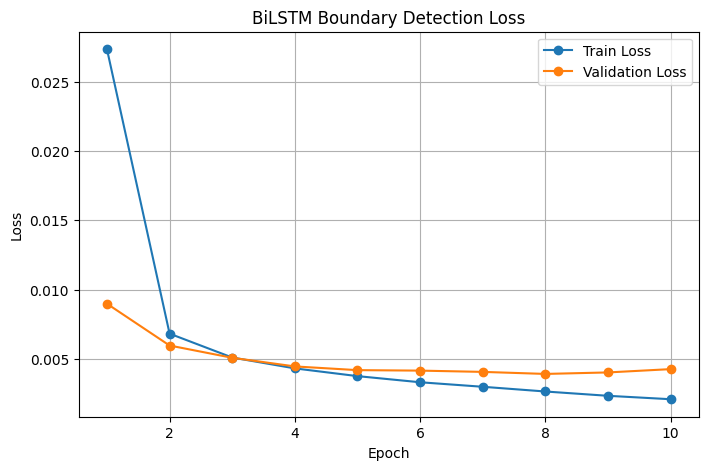

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(
    range(1, EPOCHS + 1),
    train_losses,
    marker='o',
    label="Train Loss"
)
plt.plot(
    range(1, EPOCHS + 1),
    val_losses,
    marker='o',
    label="Validation Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BiLSTM Boundary Detection Loss")
plt.legend()
plt.grid(True)
plt.show()

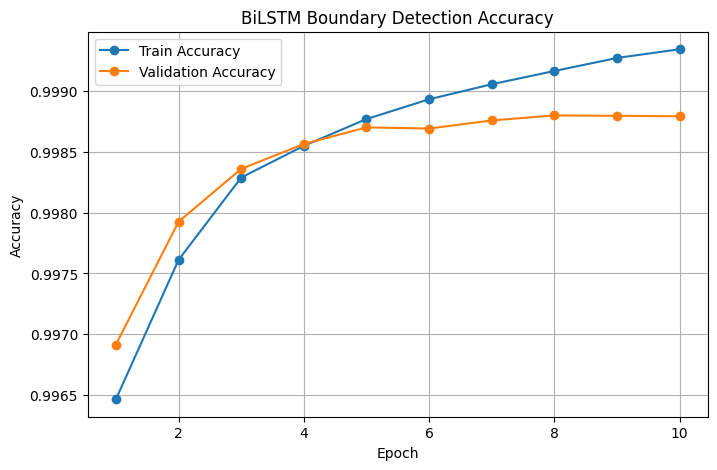

In [20]:
plt.figure(figsize=(8,5))
plt.plot(
    range(1, EPOCHS + 1),
    train_accuracies,
    marker='o',
    label="Train Accuracy"
)
plt.plot(
    range(1, EPOCHS + 1),
    val_accuracies,
    marker='o',
    label="Validation Accuracy"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("BiLSTM Boundary Detection Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Precision: 0.8954918032786885
Recall   : 0.7817531305903399
F1 Score : 0.8347659980897804


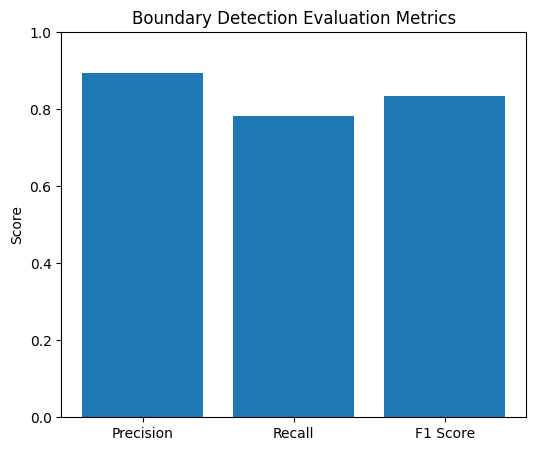

In [21]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

def evaluate_metrics(model, dataloader):

    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            outputs = model(x)
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).int()
            all_preds.extend(
                preds.cpu().numpy().flatten()
            )
            all_labels.extend(
                y.numpy().flatten()
            )
    precision = precision_score(
        all_labels,
        all_preds
    )
    recall = recall_score(
        all_labels,
        all_preds
    )
    f1 = f1_score(
        all_labels,
        all_preds
    )
    return precision, recall, f1

precision, recall, f1 = evaluate_metrics(
    model,
    val_loader
)

print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

metrics = [
    "Precision",
    "Recall",
    "F1 Score"
]

values = [
    precision,
    recall,
    f1
]

plt.figure(figsize=(6,5))
plt.bar(metrics, values)
plt.ylim(0,1)
plt.ylabel("Score")
plt.title(
    "Boundary Detection Evaluation Metrics"
)
plt.show()

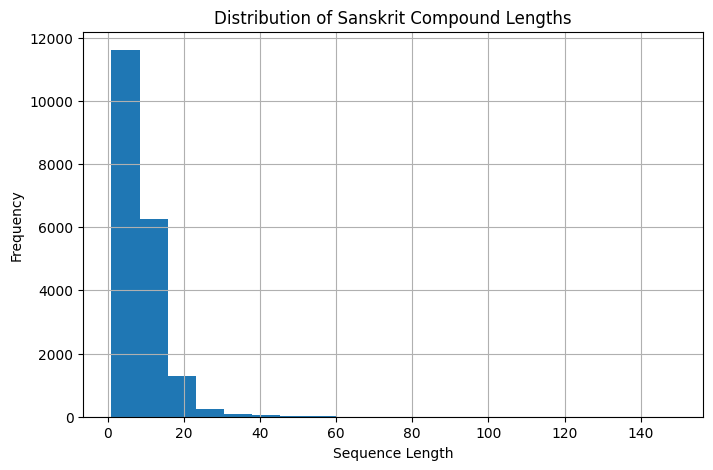

In [22]:
sequence_lengths = word_df["sandhied"].apply(len)
plt.figure(figsize=(8,5))
plt.hist(
    sequence_lengths,
    bins=20
)
plt.xlabel("Sequence Length")
plt.ylabel("Frequency")
plt.title("Distribution of Sanskrit Compound Lengths")
plt.grid(True)

In [23]:
samples = word_df.sample(5)

for _, row in samples.iterrows():
    word = row["sandhied"]
    gold = row["boundary_positions"]
    pred_boundary, probs = predict_boundary(word)
    print("WORD:")
    print(word)
    print("\nGOLD:")
    print(gold)
    print("\nPREDICTED:")
    print(pred_boundary)
    print("\nWINDOW:")
    print(make_window(
            word,
            pred_boundary)
         )
    print("-" * 60)

WORD:
एव

GOLD:
[]

PREDICTED:
1

WINDOW:
ए+व
------------------------------------------------------------
WORD:
वा

GOLD:
[]

PREDICTED:
2

WINDOW:
वा+
------------------------------------------------------------
WORD:
पूरय

GOLD:
[]

PREDICTED:
3

WINDOW:
पूर+य
------------------------------------------------------------
WORD:
तित्तिरिवरतन्तुखण्डिकोखाच्छण्

GOLD:
[26]

PREDICTED:
26

WINDOW:
ुखण्डिकोखाच्+छण्
------------------------------------------------------------
WORD:
श्रीमद्राधारमणवपुषाऽऽश्वास्य

GOLD:
[19]

PREDICTED:
7

WINDOW:
श्रीमद्+राधारमणवपुषा
------------------------------------------------------------


## ByT5 Restoration Training

In [24]:
!pip install -q -U transformers accelerate
from datasets import Dataset as HFDataset
from transformers import (
    AutoTokenizer,
    T5ForConditionalGeneration,
    TrainingArguments,
    Trainer,
    DataCollatorForSeq2Seq
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 85.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 668.2/668.2 kB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 114.4 MB/s eta 0:00:00


In [25]:
restoration_samples = []
for _, row in word_df.iterrows():

    word = row["sandhied"]
    split = row["gold_split"]
    positions = row["boundary_positions"]
    if len(positions) == 0:
        continue
    boundary = positions[0]
    window = make_window(
        word,
        boundary
    )
    restoration_samples.append({
        "input_text":
            f"split: {window}",
        "target_text":
            split
    })

restoration_df = pd.DataFrame(
    restoration_samples
)

restoration_df.head()

,input_text,target_text
0,split: प्रथमो+ऽङ्कः,प्रथमः+अङ्कः
1,split: खल्+वेष,खलु+एषः
2,split: हनुमांश+्च,हनुमान्+च
3,split: मम+ापि,मम+अपि
4,split: किमस+ि,किम्+असि


In [26]:
train_data, temp_data = train_test_split(
    restoration_samples,
    test_size=0.2,
    random_state=42
)

val_data, test_data = train_test_split(
    temp_data,
    test_size=0.5,
    random_state=42
)

print("Train:", len(train_data))
print("Val:", len(val_data))
print("Test:", len(test_data))

Train: 8853
Val: 1107
Test: 1107


In [27]:
train_dataset = HFDataset.from_list(train_data)
val_dataset = HFDataset.from_list(val_data)

In [28]:
model_name = "google/byt5-small"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = T5ForConditionalGeneration.from_pretrained(
    model_name
)

config.json:   0%|          | 0.00/698 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.59k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.50k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/172 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [29]:
def preprocess_function(examples):

    model_inputs = tokenizer(

        examples["input_text"],

        max_length=48,

        truncation=True
    )

    labels = tokenizer(

        examples["target_text"],

        max_length=48,
        

        truncation=True
    )

    model_inputs["labels"] = labels["input_ids"]

    return model_inputs

In [30]:
train_dataset = train_dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=["input_text", "target_text"]
)

val_dataset = val_dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=["input_text", "target_text"]
)

Map:   0%|          | 0/8853 [00:00<?, ? examples/s]

Map:   0%|          | 0/1107 [00:00<?, ? examples/s]

In [31]:
training_args = TrainingArguments(

    output_dir="./byt5_sandhi",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=5e-5,

    per_device_train_batch_size=16,

    num_train_epochs=5,

    warmup_steps=50,

    weight_decay=0.01,

    logging_steps=20,

    dataloader_num_workers=2,

    fp16=torch.cuda.is_available(),

    report_to="none",

    max_grad_norm=1.0
)

In [32]:
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True,
    label_pad_token_id=-100
)

In [33]:
trainer = Trainer(

    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
)
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss
1,0.492674,0.318215
2,0.322260,0.240594
3,0.289803,0.218373
4,0.253347,0.211155
5,0.272078,0.206796


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1385, training_loss=0.5193852297235482, metrics={'train_runtime': 1297.1439, 'train_samples_per_second': 34.125, 'train_steps_per_second': 1.068, 'total_flos': 3812667190824960.0, 'train_loss': 0.5193852297235482, 'epoch': 5.0})

In [34]:
SAVE_PATH = "/kaggle/working/byt5_sandhi_model"

trainer.save_model(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)
print("Model saved to:", SAVE_PATH)

import shutil

shutil.make_archive(
    "/kaggle/working/byt5_sandhi_model",
    'zip',
    SAVE_PATH
)

print("ZIP file created")

import pandas as pd
history_df = pd.DataFrame(
    trainer.state.log_history
)

history_df.head()
history_df.to_csv(
    "/kaggle/working/byt5_training_logs.csv",
    index=False
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: /kaggle/working/byt5_sandhi_model
ZIP file created


## Final Analysis

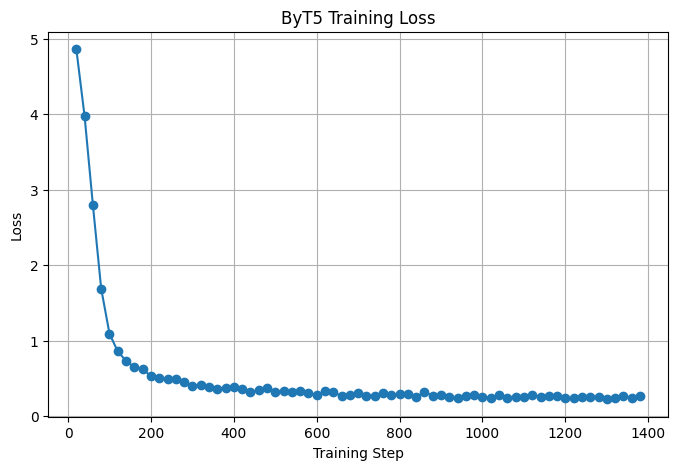

In [35]:
import matplotlib.pyplot as plt

train_logs = history_df.dropna(
    subset=["loss"]
)

plt.figure(figsize=(8,5))

plt.plot(
    train_logs["step"],
    train_logs["loss"],
    marker='o'
)

plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("ByT5 Training Loss")
plt.grid(True)
plt.show()

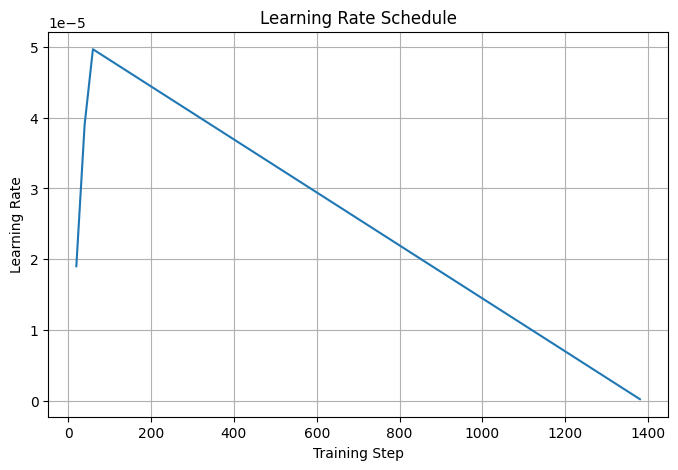

In [36]:
plt.figure(figsize=(8,5))

plt.plot(
    train_logs["step"],
    train_logs["learning_rate"]
)

plt.xlabel("Training Step")
plt.ylabel("Learning Rate")
plt.title("Learning Rate Schedule")
plt.grid(True)
plt.show()

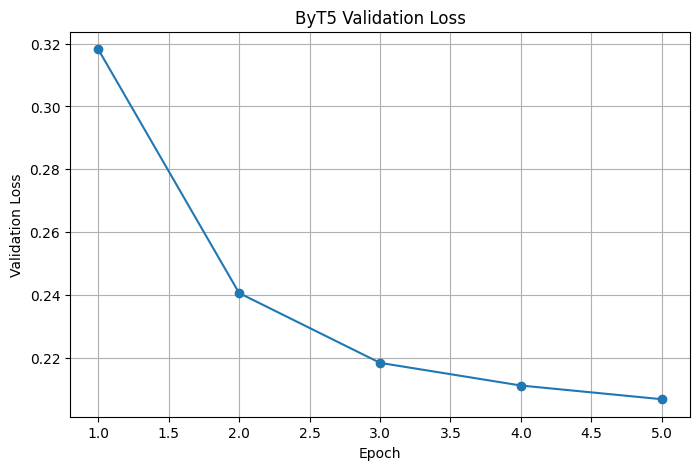

In [37]:
eval_logs = history_df.dropna(
    subset=["eval_loss"]
)

plt.figure(figsize=(8,5))

plt.plot(
    eval_logs["epoch"],
    eval_logs["eval_loss"],
    marker='o'
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("ByT5 Validation Loss")
plt.grid(True)
plt.show()

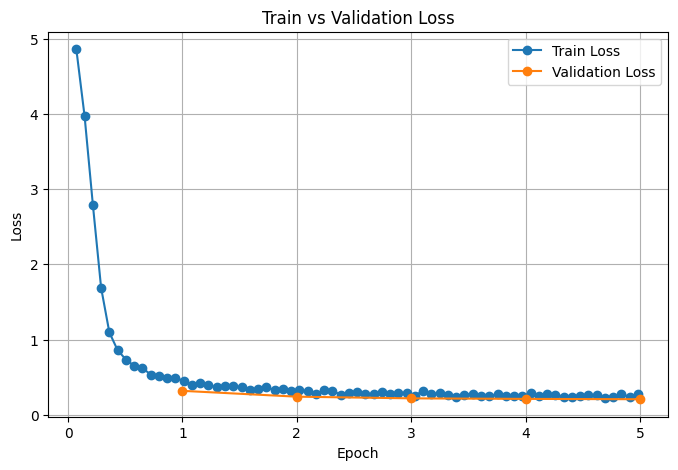

In [38]:
train_epoch_logs = train_logs.groupby(
    "epoch"
)["loss"].mean()

plt.figure(figsize=(8,5))

plt.plot(
    train_epoch_logs.index,
    train_epoch_logs.values,
    marker='o',
    label="Train Loss"
)

plt.plot(
    eval_logs["epoch"],
    eval_logs["eval_loss"],
    marker='o',
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

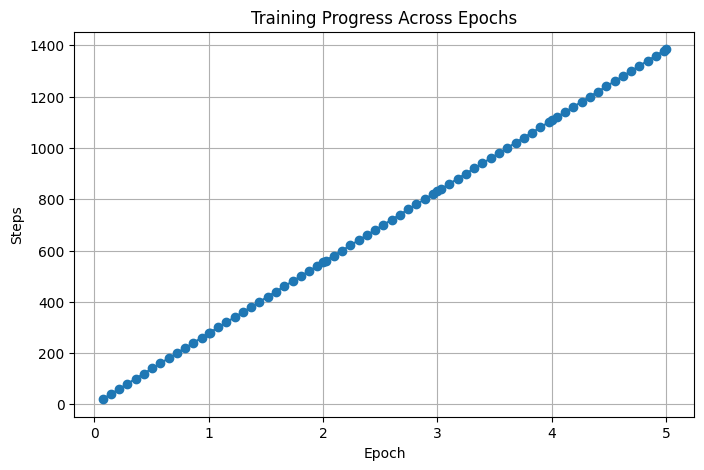

In [39]:
steps_per_epoch = history_df.groupby(
    "epoch"
)["step"].max()

plt.figure(figsize=(8,5))

plt.plot(
    steps_per_epoch.index,
    steps_per_epoch.values,
    marker='o'
)

plt.xlabel("Epoch")
plt.ylabel("Steps")
plt.title("Training Progress Across Epochs")
plt.grid(True)
plt.show()